In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from tqdm import tqdm
import seaborn as sns

# allow imports from utils/
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load colors

In [2]:
# Create legend for chromosomes
c32_palette = [
    (173, 216, 230),
    (0, 0, 255),
    (72, 61, 139),
    (123, 104, 238),
    (138, 43, 226),
    (128, 0, 128),
    (218, 112, 214),
    (255, 20, 147),
    (176, 48, 96),
    (220, 20, 60),
    (240, 128, 128),
    (255, 69, 0),
    (255, 165, 0),
    (244, 164, 96),
    (240, 230, 140),
    (128, 128, 0),
    (139, 69, 19),
    (255, 255, 0),
    (154, 205, 50),
    (124, 252, 0),
    (34, 139, 34),
    (0, 255, 255),
    (0, 139, 139),
    (128, 128, 128),
]

from colormap import rgb2hex

c32_palette = [rgb2hex(c[0], c[1], c[2]) for c in c32_palette]


colors = list(c32_palette)
chr_colors_dict = {
    f"chr{chrom}": colors[chrom - 1] for chrom in np.arange(1, 22 + 1, 1)
}

# Load IMR90 lncRNA binding site data

In [3]:
from ast import literal_eval

bs_data = pd.read_csv('../data/imr90/imr90_specific_ncrna_dna_bs_data_all_expressed.csv.gz')
bs_data.ia_chromosome = np.array(bs_data.ia_chromosome).astype(str)
bs_data.ts_chromosome = np.array(bs_data.ts_chromosome).astype(str)

bs_data.ia_loci = bs_data.ia_loci.apply(lambda x: literal_eval(x) if "[" in x else x)
bs_data.ts_loci = bs_data.ts_loci.apply(lambda x: literal_eval(x) if "[" in x else x)
bs_data["bs_idx"] = np.array(bs_data.index)

bs_data.head(3)

,idx,ncName,ncID,loci,annotation,rsID,interDescription,experiment,reference,gse,...,ts_chromosome,ts_length,ia_chromosome,iass,iaes,ia_length,closest_gene,ia_loci,bs_idx,ts_loci
0,ncGI-503111212,LINC02453,NONHSAG012022,chr1:1473892-1473926,ENSG00000205090/TMEM240/intron,-,-,iMARGI,30718424,GSE122690,...,12,18312.0,1,1473892,1473926,34,ENSG00000205090,[chr1_loc_1250000],0,[chr12_loc_98750000]
1,ncGI-503111215,LINC02453,NONHSAG012022,chr1:2567807-2567905,ENSG00000215912/TTC34/UTR;ENSG00000237058/RP13...,-,-,iMARGI,30718424,GSE122690,...,12,18312.0,1,2567807,2567905,98,ENSG00000237058,[chr1_loc_2500000],1,[chr12_loc_98750000]
2,ncGI-503111221,LINC02453,NONHSAG012022,chr1:6903425-6903523,ENSG00000171735/CAMTA1/intron,-,-,iMARGI,30718424,GSE122690,...,12,18312.0,1,6903425,6903523,98,ENSG00000171735,[chr1_loc_6750000],2,[chr12_loc_98750000]


In [4]:
resolutions = [0, 100, 1e3, 10e3, 50e3, 100e3, 150e3, 250e3, 500e3]
ncrnas = bs_data.ncID_ensembl.unique()

In [5]:
merging_bs_data = pd.read_csv("../data/imr90/merged_bs_by_resolution_summary.csv.gz",index_col=0)

In [6]:
median_bs_count = []
mean_bs_count = []
p75_bs_count = []
p25_bs_count = []
max_bs_count = []
resolutions = np.unique(merging_bs_data.resolution)

for res in resolutions:
    entry = merging_bs_data.loc[merging_bs_data.resolution == res]
    bs_count = entry.groupby("ncID_ensembl").count().iloc[:, 0]
    median_bs_count.append(np.median(bs_count))
    mean_bs_count.append(np.mean(bs_count))
    p25_bs_count.append(np.percentile(bs_count, 25))
    p75_bs_count.append(np.percentile(bs_count, 75))
    max_bs_count.append(np.max(bs_count))

## Fig S5a

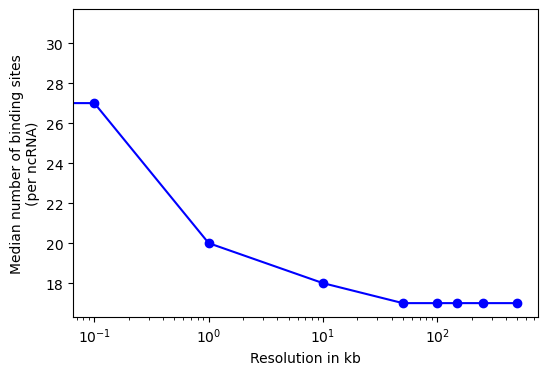

In [16]:
fig, ax = plt.subplots(figsize=[6, 4])
ax.plot(resolutions / 1e3, median_bs_count, c="b", label="Median")
ax.scatter(resolutions / 1e3, median_bs_count, c="b", label="Median")
plt.xlabel("Resolution in kb")
plt.ylabel("Median number of binding sites\n(per ncRNA)")
plt.xscale("log")
plt.savefig('./figS4a.svg', bbox_inches = 'tight')

## 3. Genome-wide study of the distribution of ncRNA binding sites

We will now study the distribution of the binding sites for each ncRNA in more detail. From now on all analyses will be on an 250kb loci level, i.e. binding sites within the same 250kb loci are merged and treated as one. Similarly, we will study their transcription sites on a 250kb loci level.

In [8]:
bs_data_exploded = (
    bs_data.copy()
    .drop(columns=["ts_loci"])
    .set_index(list(set(bs_data.columns) - {"ia_loci", "ts_loci"}))
    .apply(pd.Series.explode)
    .reset_index()
)
selected_cols = list(bs_data.columns)
selected_cols.remove("ts_loci")
bs_data_exploded = bs_data_exploded.loc[:, selected_cols]

bs_data_exploded["ts_loci"] = np.array(bs_data.loc[bs_data_exploded.bs_idx, "ts_loci"])
bs_data_exploded = (
    bs_data_exploded.copy()
    .set_index(list(set(bs_data_exploded.columns) - {"ts_loci"}))
    .apply(pd.Series.explode)
    .reset_index()
)
selected_cols = list(bs_data.columns)
bs_data_exploded = bs_data_exploded.loc[:, selected_cols]

In [9]:
bs_overview = {
    "ncID_ensembl": [],
    "n_bs_in_ts_locus": [],
    "n_bs_on_ts_chromosome": [],
    "n_bs_on_ts_chromosome_but_not_ts_locus": [],
    "n_bs_on_other_chromosome": [],
    "n_total_bs": [],
    "n_total_bs_chr": [],
    "ts_chromosome": [],
}
for i in range(1, 23):
    bs_overview["bs_prop_chr{}".format(i)] = []

for i in range(1, 23):
    bs_overview["loci_prop_chr{}".format(i)] = []

ncrnas = bs_data_exploded.ncID_ensembl.unique()

for ncrna in tqdm(ncrnas):
    entry = bs_data_exploded.loc[bs_data_exploded.ncID_ensembl == ncrna]
    bs_overview["ncID_ensembl"].append(ncrna)

    ts_loci = entry.ts_loci.unique()
    ts_locus_bs_entry = entry.loc[entry.ia_loci.isin(ts_loci)]
    n_bs_in_ts_locus = len(ts_locus_bs_entry.bs_idx.unique())

    ts_chromosome = entry.ts_chromosome.unique()
    ts_chr_bs_entry = entry.loc[entry.ia_chromosome.isin(ts_chromosome)]
    n_bs_on_ts_chromosome = len(ts_chr_bs_entry.bs_idx.unique())

    ts_chr_bs_entry = ts_chr_bs_entry.loc[~ts_chr_bs_entry.ia_loci.isin(ts_loci)]
    n_bs_on_ts_chromosome_but_not_ts_locus = len(ts_chr_bs_entry.bs_idx.unique())

    other_chr_bs_entry = entry.loc[~entry.ia_chromosome.isin(ts_chromosome)]
    n_bs_on_other_chromosome = len(other_chr_bs_entry.bs_idx.unique())

    bs_overview["n_bs_in_ts_locus"].append(n_bs_in_ts_locus)
    bs_overview["n_bs_on_ts_chromosome_but_not_ts_locus"].append(
        n_bs_on_ts_chromosome_but_not_ts_locus
    )
    bs_overview["n_bs_on_ts_chromosome"].append(n_bs_on_ts_chromosome)
    bs_overview["n_bs_on_other_chromosome"].append(n_bs_on_other_chromosome)
    bs_overview["n_total_bs"].append(len(entry.bs_idx.unique()))
    bs_overview["n_total_bs_chr"].append(len(entry.ia_chromosome.unique()))

    for i in range(1, 23):
        e = entry.loc[entry.ia_chromosome == str(i)]
        bs_overview["bs_prop_chr{}".format(i)].append(
            e.bs_idx.nunique() / entry.bs_idx.nunique()
        )
        bs_overview["loci_prop_chr{}".format(i)].append(
            e.ia_loci.nunique() / entry.ia_loci.nunique()
        )
    bs_overview["ts_chromosome"].append(ts_chromosome[0])


bs_overview = pd.DataFrame(bs_overview)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1888/1888 [00:50<00:00, 37.75it/s]


In [10]:
gex_data = pd.read_csv("../data/imr90/rnaseq/gingeras_data.csv", index_col=0)
norm_bs_overview = bs_overview.copy()
for i in range(1, 5):
    norm_bs_overview.iloc[:, i] = (
        norm_bs_overview.iloc[:, i] / norm_bs_overview.n_total_bs
    )
norm_bs_overview.loc[:, "log_TPM"] = np.array(
    gex_data.loc[norm_bs_overview.ncID_ensembl, "log_TPM"]
)

## Fig S1b

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


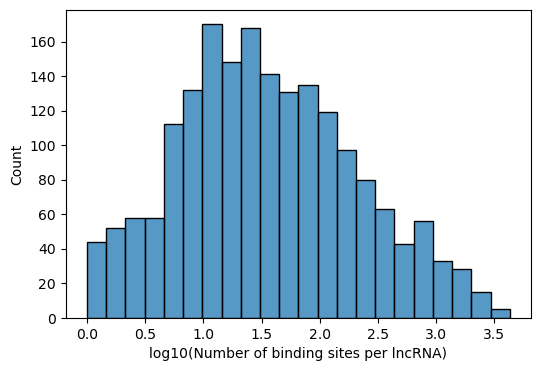

In [11]:
fig, ax = plt.subplots(figsize=[6, 4])
ax = sns.histplot(
    x=np.log10(norm_bs_overview["n_total_bs"]),
)
ax.set_xlabel("log10(Number of binding sites per lncRNA)")
plt.savefig("./S1b.svg", bbox_inches = 'tight')
plt.show()

## Fig S1c

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


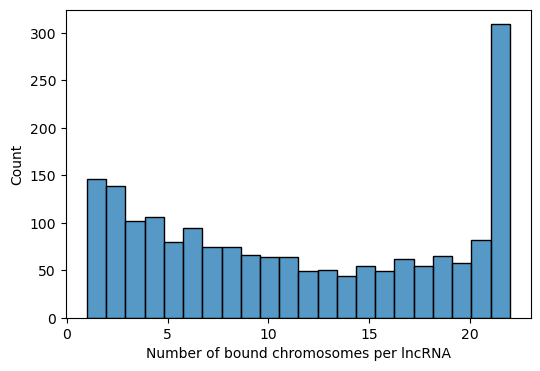

In [12]:
fig, ax = plt.subplots(figsize=[6, 4])
ax = sns.histplot(
    data=norm_bs_overview,
    x="n_total_bs_chr",
    bins=22,
)
ax.set_xlabel("Number of bound chromosomes per lncRNA")
plt.savefig("./S1c.svg", bbox_inches = 'tight')
plt.show()

## Fig S1d

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


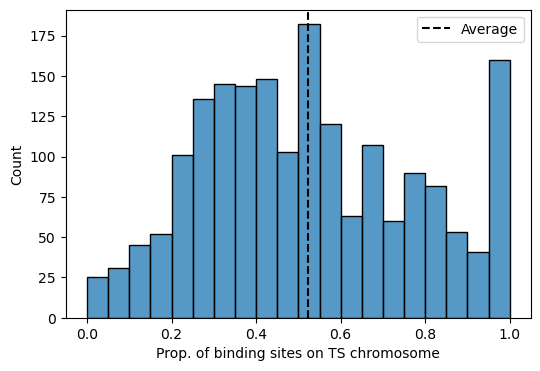

In [13]:
mean = np.mean(norm_bs_overview["n_bs_on_ts_chromosome"])

fig, ax = plt.subplots(figsize=[6, 4])
ax = sns.histplot(data=norm_bs_overview, x="n_bs_on_ts_chromosome", bins=20)
ax.set_xlabel("Prop. of binding sites on TS chromosome")
ax.axvline(x=mean, linestyle="--", color="black", label="Average")
plt.legend()
plt.savefig("./S1d.svg", bbox_inches = 'tight')

plt.show()

## Fig S1e

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


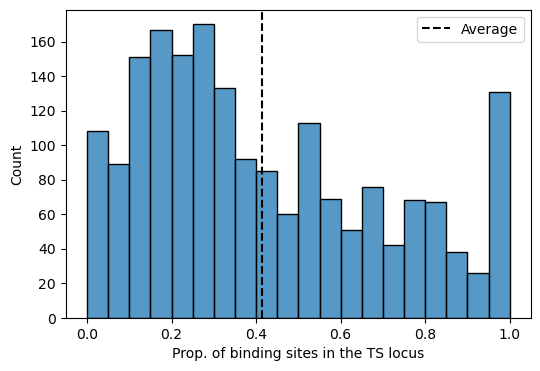

In [14]:
mean = np.mean(norm_bs_overview["n_bs_in_ts_locus"])

fig, ax = plt.subplots(figsize=[6, 4])
ax = sns.histplot(data=norm_bs_overview, x="n_bs_in_ts_locus", bins=20)
ax.set_xlabel("Prop. of binding sites in the TS locus")
ax.axvline(x=mean, linestyle="--", color="black", label="Average")
plt.legend()
plt.savefig("./S1e.svg", bbox_inches = 'tight')
plt.show()

## Fig 1b

Furthermore, as expected we observe primarily ncRNAs that have many different binding loci to show binding less concentrated around the transcription site.

In [32]:
# Filter out 5 ncRNAs with all binding sites on the same chromosome
# would result into an unidentified correlation metrics

selected_cols = []
for col in bs_overview.columns:
    if "bs_prop" in col:
        selected_cols.append(col)
print(selected_cols)

tmp = bs_overview.loc[bs_overview.loc[:, selected_cols].sum(axis=1) != 0]
tmp2 = norm_bs_overview.loc[norm_bs_overview.loc[:, selected_cols].sum(axis=1) != 0]

selected_ncrnas = set(list(tmp.iloc[:, 0])).intersection(list(tmp2.iloc[:, 0]))

selection_idx = []
for i in range(23):
    selection_idx.extend(
        list(bs_data.loc[bs_data.ts_chromosome == str(i), "ncID_ensembl"].unique())
    )
cleaned_selection_idx = []
for idx in selection_idx:
    if idx in selected_ncrnas:
        cleaned_selection_idx.append(idx)
tmp.index = tmp.iloc[:, 0]
tmp = tmp.loc[cleaned_selection_idx]
row_colors = list(pd.Series(np.array("chr" + tmp.ts_chromosome)).map(chr_colors_dict))
col_colors = list(
    pd.Series(["chr{}".format(i) for i in range(1, 23)]).map(chr_colors_dict)
)
tmp = tmp.loc[:, selected_cols]

['bs_prop_chr1', 'bs_prop_chr2', 'bs_prop_chr3', 'bs_prop_chr4', 'bs_prop_chr5', 'bs_prop_chr6', 'bs_prop_chr7', 'bs_prop_chr8', 'bs_prop_chr9', 'bs_prop_chr10', 'bs_prop_chr11', 'bs_prop_chr12', 'bs_prop_chr13', 'bs_prop_chr14', 'bs_prop_chr15', 'bs_prop_chr16', 'bs_prop_chr17', 'bs_prop_chr18', 'bs_prop_chr19', 'bs_prop_chr20', 'bs_prop_chr21', 'bs_prop_chr22']


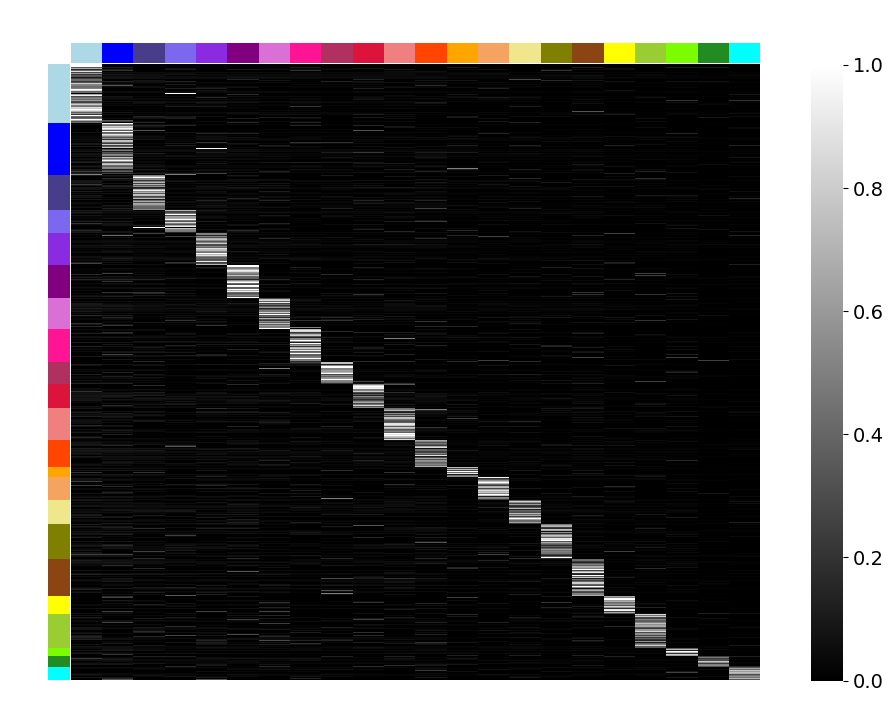

In [33]:
g = sns.clustermap(
    tmp,
    row_colors=row_colors,
    col_colors=col_colors,
    row_cluster=False,
    col_cluster=False,
    dendrogram_ratio=0.05,
    # cbar_pos=None,
    xticklabels=False,
    yticklabels=False,
    figsize=[8, 7],
    cmap="gist_gray",
)
ax = g.ax_heatmap
ax.set_ylabel(None)
# ax.set_xlabel("Binding site in", fontsize = 20)
fig.suptitle(
    "Chromosome-level colocalization of binding and transcription sites",
)
g.ax_cbar.set_position([1.02, 0.02, 0.04, 0.88])
g.ax_cbar.set_position([1.02, 0.02, 0.04, 0.88])
g.ax_cbar.set_ylabel(None)
g.ax_cbar.tick_params(labelsize=14)  # increase label size to 14
plt.show()

In [34]:
selected_cols = ["n_bs_in_ts_locus", "n_bs_on_ts_chromosome_but_not_ts_locus"]

tmp2.index = tmp2.iloc[:, 0]
tmp2 = tmp2.loc[cleaned_selection_idx]
row_colors = list(pd.Series(np.array("chr" + tmp2.ts_chromosome)).map(chr_colors_dict))
# col_colors = list(pd.Series(list(range(1, 23))).map(chr_colors_dict))
tmp2 = tmp2.loc[:, selected_cols]

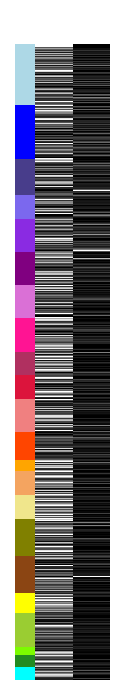

In [35]:

g = sns.clustermap(
    tmp2,
    row_colors=row_colors,
    # col_colors=col_colors,
    row_cluster=False,
    col_cluster=False,
    dendrogram_ratio=0.05,
    # cbar_pos=None,
    xticklabels=False,
    yticklabels=False,
    figsize=[1.5, 7],
    cmap="gist_gray",
    colors_ratio=0.2,
)
g.cax.set_visible(False)
ax = g.ax_heatmap
ax.set_ylabel(None)
# ax.set_xlabel("Binding site in")
fig.suptitle(
    "Chromosome-level colocalization of binding and transcription sites",
)
g.ax_cbar.set_position([1.02, 0.02, 0.04, 0.88])
g.ax_cbar.set_position([1.02, 0.02, 0.04, 0.88])
# g.ax_cbar.set_ylabel("Proportion falling into the chromosome")

plt.show()

We also observe that in general the total number of reported binding locations (which can partially overlap) are found on the same chromosome as the respective transcription site of the noncoding gene. This is seen in the heatmap above. Interestingly, if we however merge all binding sites that fall into the same locus this overall trend is less pronounced, yet still present.

In [36]:
from natsort import natsorted

tmp = bs_data_exploded.groupby("ts_loci").ncID_ensembl.nunique()
tmp = tmp.loc[natsorted(tmp.index)]
tmp = pd.DataFrame(np.array(tmp), index=tmp.index, columns=["n_ncrna_tss"])
tmp["locus_id"] = np.array(tmp.index)
tmp["chrom"] = tmp.locus_id.apply(lambda x: x.split("_")[0])
tmp["locus"] = tmp.locus_id.apply(lambda x: int(x.split("_")[-1]))

for chrom in tqdm(range(1, 23)):
    entry
    entry = tmp.loc[tmp.chrom == "chr{}".format(chrom)]
    max_locus = entry["locus"].max()
    for i in range(0, int(max_locus), 250000):
        locus_id = "chr{}_loc_{}".format(chrom, i)
        if locus_id not in tmp.index:
            tmp = pd.concat(
                [
                    tmp,
                    pd.DataFrame(
                        {
                            "n_ncrna_tss": [0],
                            "locus_id": [locus_id],
                            "locus": [i],
                            "chrom": ["chr{}".format(chrom)],
                        },
                        index=[locus_id],
                    ),
                ]
            )
tmp = tmp.loc[natsorted(tmp.index)]
tmp.head()

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:07<00:00,  2.84it/s]


,n_ncrna_tss,locus_id,chrom,locus
chr1_loc_0,0,chr1_loc_0,chr1,0
chr1_loc_250000,0,chr1_loc_250000,chr1,250000
chr1_loc_500000,0,chr1_loc_500000,chr1,500000
chr1_loc_750000,5,chr1_loc_750000,chr1,750000
chr1_loc_1000000,2,chr1_loc_1000000,chr1,1000000


## Fig S2

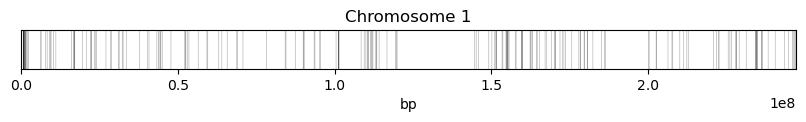

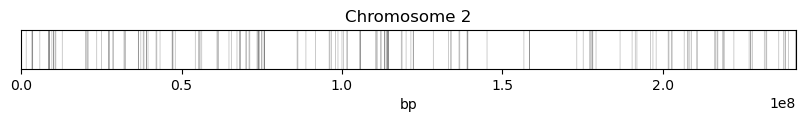

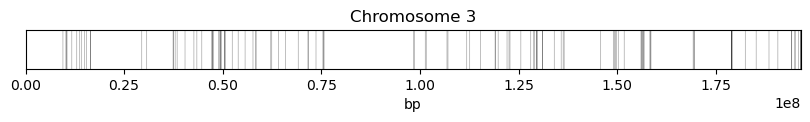

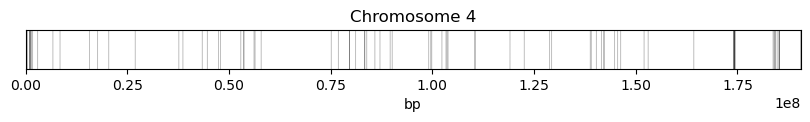

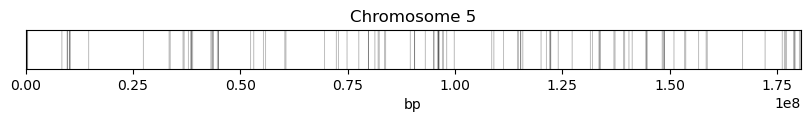

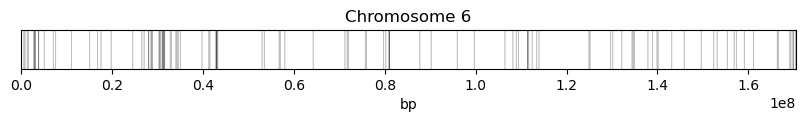

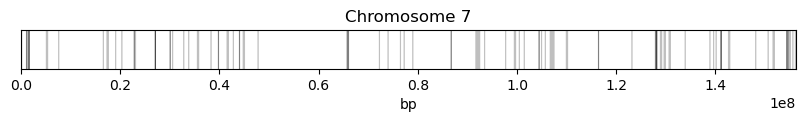

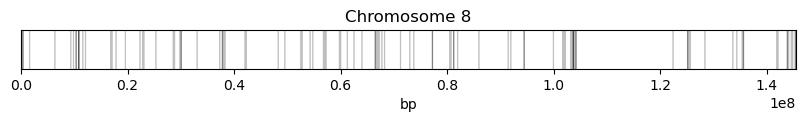

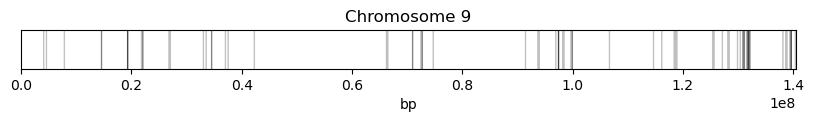

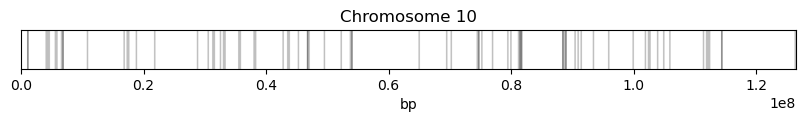

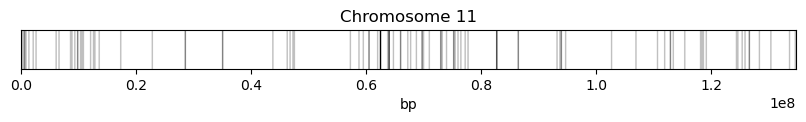

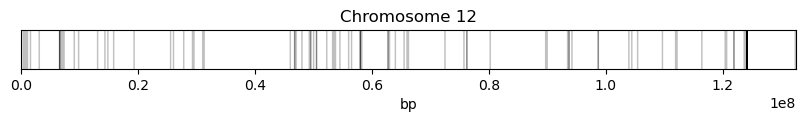

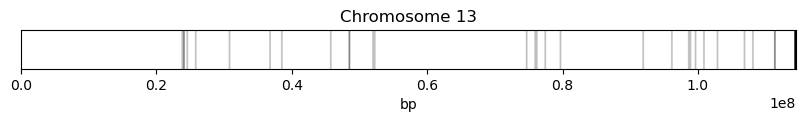

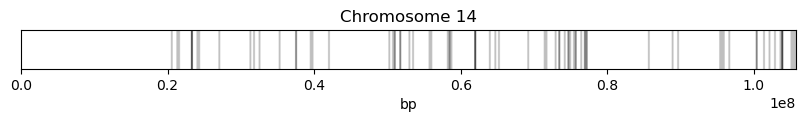

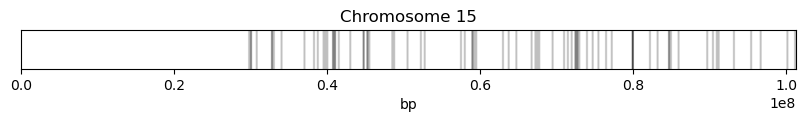

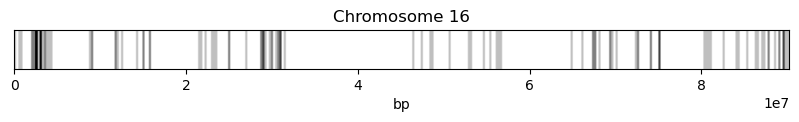

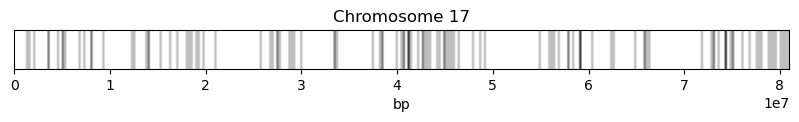

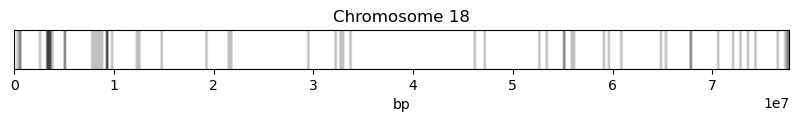

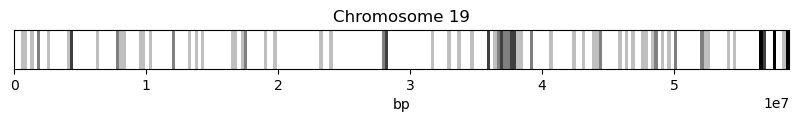

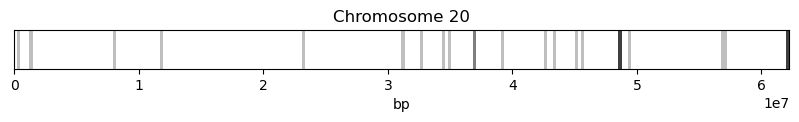

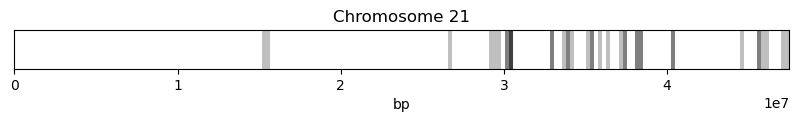

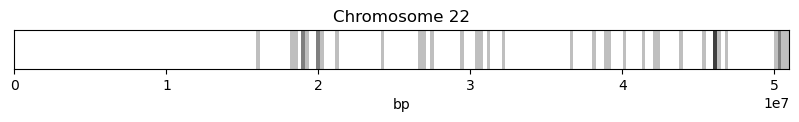

In [37]:
for chrom in range(1, 23):
    fig, ax = plt.subplots(figsize=[10, 2])
    entry = tmp.loc[tmp.chrom == "chr{}".format(chrom)]
    ax.imshow(
        np.array(entry.loc[:, "n_ncrna_tss"]).reshape(1, -1),
        cmap="binary",
        vmin=0,
        vmax=4,
        extent=[
            0,
            int(entry.loc[:, "locus"].max()),
            0,
            int(entry.loc[:, "locus"].max()) // 2000,
        ],
        aspect=100,
    )
    ax.set_title("Chromosome {}".format(chrom))
    # ax.xticks("off")
    # ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    ax.set_xlabel("bp")
    plt.show()
    plt.close()

# Activity of the ncRNA bound regions

In [39]:
# cistromic loci activity
loci_activity = pd.read_csv("../data/imr90/cistromic/loci_activity.csv")

loci_activity.columns = ["locus_id", "activity"]
loci_activity.index = loci_activity["locus_id"]
loci_chroms = []
for i in tqdm(range(len(loci_activity))):
    loci_chroms.append(int(loci_activity.iloc[i]["locus_id"].split("_")[0][3:]))
loci_activity["chromosome"] = np.array(loci_chroms)

100%|█████████████████████████████████████████████████████████████████████████████████████| 11537/11537 [00:00<00:00, 56766.29it/s]


In [40]:
loci_activity.index = loci_activity.locus_id
bs_data_exploded["ia_loci_activity"] = np.array(
    loci_activity.loc[bs_data_exploded.ia_loci, "activity"]
)
bs_data_exploded["ts_loci_activity"] = np.array(
    loci_activity.loc[bs_data_exploded.ts_loci, "activity"]
)

## Fig 1c

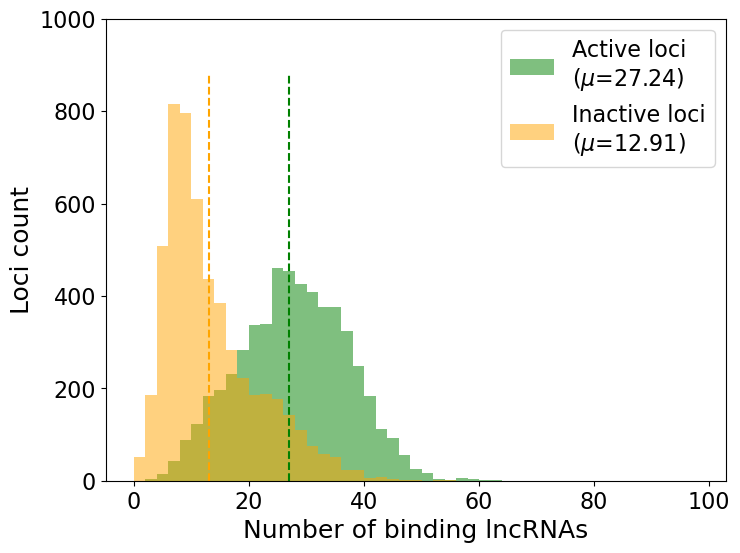

In [41]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))  # optional: make figure larger

# Active loci histogram
a_ncrna_per_locus = (
    bs_data_exploded.loc[bs_data_exploded.ia_loci_activity == "Active"]
    .groupby("ia_loci")["ncID_ensembl"]
    .nunique()
    .to_frame()
)

plt.hist(
    a_ncrna_per_locus["ncID_ensembl"],
    bins=np.arange(0, 100, 2),
    label=f'Active loci\n($\mu$={np.round(a_ncrna_per_locus["ncID_ensembl"].mean(), 2)})',
    alpha=0.5,
    color="green",
)

active_mean = np.round(a_ncrna_per_locus["ncID_ensembl"].mean())
plt.axvline(x=active_mean, c="green", linestyle="--", ymax=0.88)

# Inactive loci histogram
ia_ncrna_per_locus = (
    bs_data_exploded.loc[bs_data_exploded.ia_loci_activity == "Inactive"]
    .groupby("ia_loci")["ncID_ensembl"]
    .nunique()
    .to_frame()
)

plt.hist(
    ia_ncrna_per_locus["ncID_ensembl"],
    bins=np.arange(0, 100, 2),
    label=f'Inactive loci\n($\mu$={np.round(ia_ncrna_per_locus["ncID_ensembl"].mean(), 2)})',
    alpha=0.5,
    color="orange",
)

inactive_mean = np.round(ia_ncrna_per_locus["ncID_ensembl"].mean())
plt.axvline(x=inactive_mean, c="orange", linestyle="--", ymax=0.88)

# Labels
plt.xlabel("Number of binding lncRNAs", fontsize=18)
plt.ylabel("Loci count", fontsize=18)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Legend
plt.legend(loc="upper right", fontsize=16)

plt.ylim([0, 1000])

plt.show()


In [42]:
from scipy.stats import ttest_ind

ttest_ind(
    np.array(a_ncrna_per_locus),
    np.array(ia_ncrna_per_locus),
    equal_var=False,
    alternative="greater",
)

TtestResult(statistic=array([85.10082486]), pvalue=array([0.]), df=array([10584.37648856]))

## Fig S3b

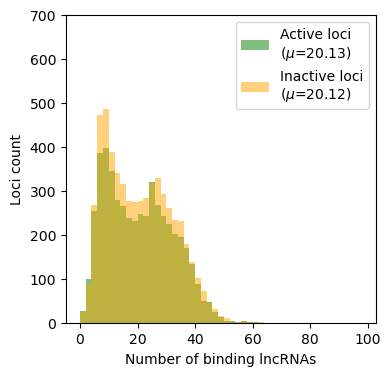

In [43]:
np.random.seed(1234)
tmp = bs_data_exploded.copy()
ia_random_activity_loci_dict = dict(
    zip(
        list(tmp.ia_loci.unique()),
        list(
            np.random.choice(list(loci_activity.activity), size=tmp.ia_loci.nunique())
        ),
    )
)

tmp.loc[:, "ia_loci_activity"] = np.array(
    bs_data_exploded.ia_loci.map(ia_random_activity_loci_dict)
)
plt.figure(figsize=[4, 4])
a_ncrna_per_locus = (
    tmp.loc[tmp.ia_loci_activity == "Active"]
    .groupby("ia_loci")["ncID_ensembl"]
    .nunique()
    .to_frame()
)

plt.hist(
    a_ncrna_per_locus["ncID_ensembl"],
    bins=np.arange(0, 100, 2),
    label=f'Active loci\n($\mu$={np.round(a_ncrna_per_locus["ncID_ensembl"].mean(), 2)})',
    alpha=0.5,
    color="green",
)
active_mean = np.round(a_ncrna_per_locus["ncID_ensembl"].mean())
# plt.axvline(x=active_mean, c="green", linestyle="--", ymax=0.88)

ia_ncrna_per_locus = (
    tmp.loc[tmp.ia_loci_activity == "Inactive"]
    .groupby("ia_loci")["ncID_ensembl"]
    .nunique()
    .to_frame()
)

plt.hist(
    ia_ncrna_per_locus["ncID_ensembl"],
    bins=np.arange(0, 100, 2),
    label=f'Inactive loci\n($\mu$={np.round(ia_ncrna_per_locus["ncID_ensembl"].mean(), 2)})',
    alpha=0.5,
    color="orange",
)

inactive_mean = np.round(ia_ncrna_per_locus["ncID_ensembl"].mean())
# plt.axvline(x=inactive_mean, c="orange", linestyle="--", ymax=0.88)

plt.xlabel("Number of binding lncRNAs")
plt.ylabel("Loci count")
plt.legend(loc="upper right")
plt.ylim([0, 700])
plt.show()

## Fig S3e

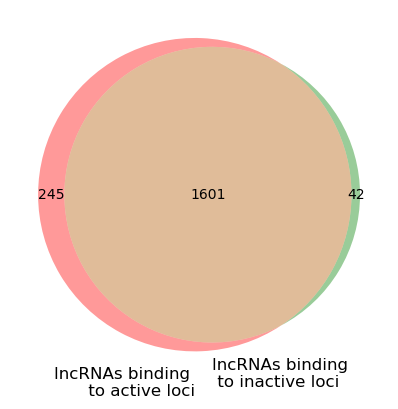

In [45]:
from matplotlib_venn import venn2

# Compare ncRNAs binding to active loci and inactive loci
ncrnas_binding_active = bs_data_exploded.loc[
    bs_data_exploded.ia_loci_activity == "Active"
]["ncID_ensembl"].unique()
ncrnas_binding_inactive = bs_data_exploded.loc[
    bs_data_exploded.ia_loci_activity == "Inactive"
]["ncID_ensembl"].unique()
ncrnas_binding_active_specific = list(
    set(ncrnas_binding_active) - set(ncrnas_binding_inactive)
)
ncrnas_binding_inactive_specific = list(
    set(ncrnas_binding_inactive) - set(ncrnas_binding_active)
)
plt.figure()
venn2(
    subsets=(set(ncrnas_binding_active), set(ncrnas_binding_inactive)),
    set_labels=(
        "lncRNAs binding \n to active loci",
        "lncRNAs binding \n to inactive loci",
    ),
)
# plt.title()
plt.show()

## Fig S3f

In [46]:
active_loci = set(loci_activity.loc[loci_activity.activity == "Active"].index)
inactive_loci = set(loci_activity.loc[loci_activity.activity == "Inactive"].index)

# Define parameters
N = len(active_loci) + len(inactive_loci)
N1 = len(active_loci)
N2 = len(inactive_loci)
K = bs_data_exploded["ncID_ensembl"].nunique()
alpha = 0.05 / (2 * K)

ncrna_data_pvals = {"ncID_ensembl": [], "active_bs": [], "inactive_bs": []}
for ncrna in tqdm(bs_data_exploded["ncID_ensembl"].unique()):
    ncrna_data_pvals["ncID_ensembl"].append(ncrna)
    entry = bs_data_exploded.loc[bs_data_exploded.ncID_ensembl == ncrna]
    ncrna_data_pvals["active_bs"].append(np.sum(entry.ia_loci_activity == "Active"))
    ncrna_data_pvals["inactive_bs"].append(np.sum(entry.ia_loci_activity == "Inactive"))
ncrna_data_pvals = pd.DataFrame(ncrna_data_pvals)
ncrna_data_pvals.loc[:, "all_bs"] = (
    ncrna_data_pvals["active_bs"] + ncrna_data_pvals["inactive_bs"]
)
ncrna_data_pvals.index = np.array(ncrna_data_pvals.ncID_ensembl)
ncrna_data_pvals = ncrna_data_pvals.iloc[:, 1:]

100%|██████████████████████████████████████████████████████████████████████████████████████████| 1888/1888 [00:32<00:00, 57.89it/s]


In [48]:
import scipy.stats as ss
ncrna_data_pvals.columns = ["m_1", "m_2", "m"]
ncrna_data_pvals.loc[:, "active_pval"] = ncrna_data_pvals.apply(
    lambda row: ss.hypergeom.sf(row["m_1"] - 1, N, N1, row["m"]), axis=1
)
ncrna_data_pvals.loc[:, "inactive_pval"] = ncrna_data_pvals.apply(
    lambda row: ss.hypergeom.sf(row["m_2"] - 1, N, N2, row["m"]), axis=1
)

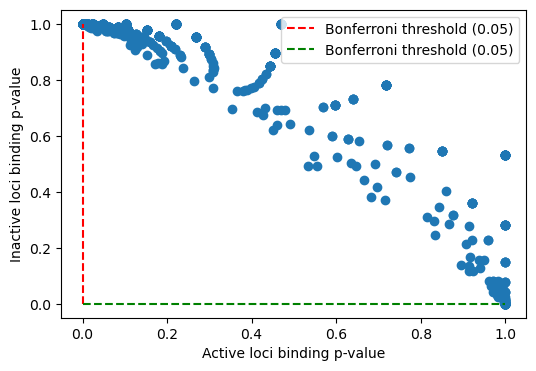

In [49]:
plt.figure(figsize=[6, 4])
plt.scatter(ncrna_data_pvals["active_pval"], ncrna_data_pvals["inactive_pval"])
plt.vlines(
    x=alpha,
    ymin=0,
    ymax=1,
    color="red",
    linestyle="dashed",
    label="Bonferroni threshold (0.05)",
)
plt.hlines(
    y=alpha,
    xmin=0,
    xmax=1,
    color="green",
    linestyle="dashed",
    label="Bonferroni threshold (0.05)",
)
plt.xlabel("Active loci binding p-value")
plt.ylabel("Inactive loci binding p-value")
plt.legend(loc="upper right")
plt.show()

## Fig 1d

In [50]:
# Select significant ncRNAs
significant_active_ncrnas = ncrna_data_pvals[
    ncrna_data_pvals["active_pval"] < alpha
].index.values
significant_inactive_ncrnas = ncrna_data_pvals[
    ncrna_data_pvals["inactive_pval"] < alpha
].index.values
active_ncrnas = list(
    set(significant_active_ncrnas).union(set(ncrnas_binding_active_specific))
)
inactive_ncrnas = list(
    set(significant_inactive_ncrnas).union(set(ncrnas_binding_inactive_specific))
)
other_ncrnas = list(
    set(ncrna_data_pvals.index.values) - set(active_ncrnas) - set(inactive_ncrnas)
)
print(
    f"Number of ncRNAs that significantly bind active sites = {len(significant_active_ncrnas)}"
)
print(f"({len(active_ncrnas)} if we include non-significant active-specific lncRNAs)")
print(
    f"Number of ncRNAs that significantly bind inactive sites = {len(significant_inactive_ncrnas)}"
)
print(
    f"({len(inactive_ncrnas)} if we include non-significant inactive-specific lncRNAs)"
)

Number of ncRNAs that significantly bind active sites = 806
(1025 if we include non-significant active-specific lncRNAs)
Number of ncRNAs that significantly bind inactive sites = 31
(73 if we include non-significant inactive-specific lncRNAs)


/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


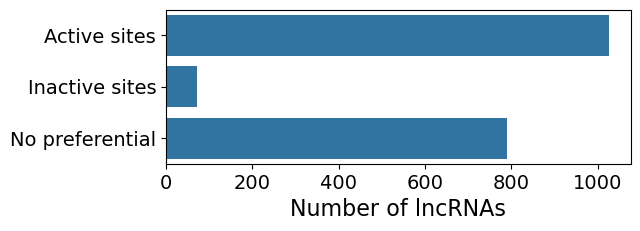

In [51]:
tmp = {
    "ncrna_type": [
        "Active sites",
        "Inactive sites",
        "No preferential",
    ],
    "n_ncrnas": [len(active_ncrnas), len(inactive_ncrnas), len(other_ncrnas)],
}

fig, ax = plt.subplots(figsize=[6, 2])

# Bar plot
ax = sns.barplot(
    data=pd.DataFrame(tmp),
    y="ncrna_type",
    x="n_ncrnas",
    palette=["tab:blue"]
)

# Axis labels
ax.set_xlabel("Number of lncRNAs", fontsize=16)  # increase x-axis label font
ax.set_ylabel("", fontsize=16)                   # increase y-axis label font (empty here)

# Increase tick label size
ax.tick_params(axis='x', labelsize=14)  # x-axis tick labels
ax.tick_params(axis='y', labelsize=14)  # y-axis tick labels

plt.show()

## Fig S3 c-d

In [56]:
# Plot as barchart of active/inactic BS per chromosome
per_chr_act = {"chromosome": [], "n_bs_loci": [], "n_bs": [], "mode": []}
for chrom in bs_data_exploded.ia_chromosome.unique():
    per_chr_act["chromosome"].append(chrom)
    per_chr_act["chromosome"].append(chrom)
    entry = bs_data_exploded.loc[bs_data_exploded.ia_chromosome == chrom]
    per_chr_act["n_bs_loci"].append(
        entry.loc[entry.ia_loci_activity == "Active", "ia_loci"].nunique()
    )
    per_chr_act["n_bs"].append(
        entry.loc[entry.ia_loci_activity == "Active", "bs_idx"].nunique()
    )
    per_chr_act["mode"].append("active")
    per_chr_act["n_bs_loci"].append(
        entry.loc[entry.ia_loci_activity == "Inactive", "ia_loci"].nunique()
    )
    per_chr_act["n_bs"].append(
        entry.loc[entry.ia_loci_activity == "Inactive", "bs_idx"].nunique()
    )
    per_chr_act["mode"].append("inactive")
per_chr_act = pd.DataFrame(per_chr_act)

In [58]:
per_chr_act.loc[:, "chromosome"] = per_chr_act.chromosome.astype(int)

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

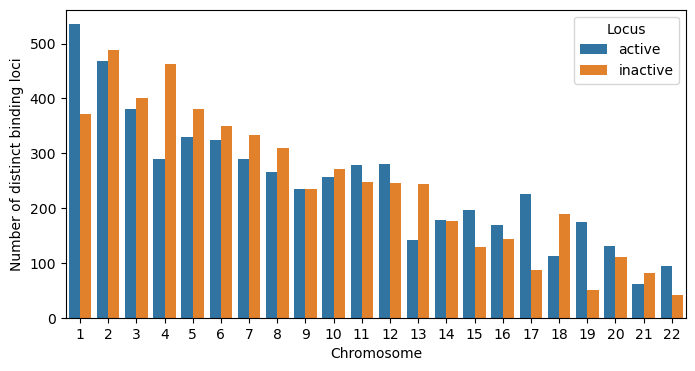

In [59]:
fig, ax = plt.subplots(figsize=[8, 4])
ax = sns.barplot(data=per_chr_act, x="chromosome", y="n_bs_loci", hue="mode")
ax.set_xlabel("Chromosome")
ax.set_ylabel("Number of distinct binding loci")
plt.legend(title="Locus")
plt.show()

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

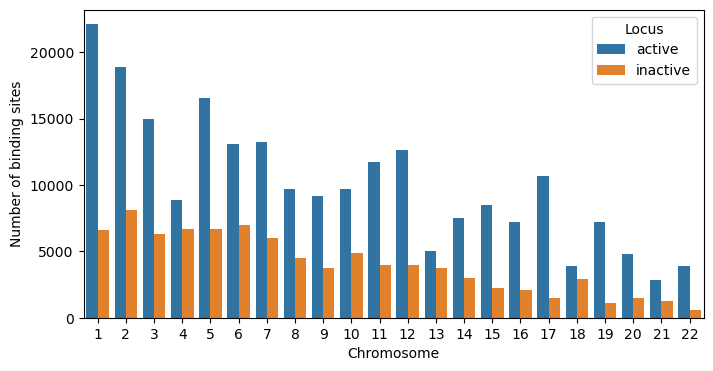

In [60]:
fig, ax = plt.subplots(figsize=[8, 4])
ax = sns.barplot(data=per_chr_act, x="chromosome", y="n_bs", hue="mode")
ax.set_xlabel("Chromosome")
ax.set_ylabel("Number of binding sites")
plt.legend(title="Locus")
plt.show()

# Functional specificity of the binding

Given that many genes bind outside of their transcription site, we are interested to assess if these regions bound by the same ncRNA that do not overlap with their transcription site (again on a loci level) have a functional meaning. To this end, for each ncRNA expressed in IMR90 we identify all protein-coding genes that overlap with any loci the ncRNA binds that is not part of the loci the transcription site of the ncRNA is located in. We then assess for each ncRNA represented by its thereby defined set of "binding target genes", if they are enriched for any pathways related to key fibroblast functions: namely any pathways related to TGF$\beta$ signaling, extracellular matrix organization or cell adhesion.

To avoid a confounding of these results with the fact that we are only looking at ncRNAs that are expressed in IMR90, we first assess if these ncRNAs genes are enriched for any of these gene sets.

In [86]:
output_file = os.path.join("../data/young_old/binding_target_data.h5")
binding_target_data = pd.read_hdf(output_file, index_col=0)

binding_target_data["locus_activity"] = "inactive"
binding_target_data.loc[
    binding_target_data.locus.isin(list(active_loci)), "locus_activity"
] = "active"

gs_data = pd.read_csv("../data/genome_data/hg19/hg19_genecode_v19_release_13.sorted.bed",
    sep="\t",
    header=None,
)
gs_data = gs_data.iloc[:, :4]
gs_data.iloc[:, 3] = np.array([s.split(".")[0] for s in gs_data.iloc[:, 3]])
gs_data.iloc[:, 0] = np.array([s[3:] for s in gs_data.iloc[:, 0]])
gs_data.columns = [
    "ts_chromosome",
    "tss",
    "tes",
    "ensembl_id",
]
gs_data.index = np.array(gs_data.ensembl_id)

def get_loci_information(
    data, resolution=250e3, start_col="tss", end_col="tes", chrom_col="ia_chromosome"
):
    all_loci = []
    for i in tqdm(range(len(data))):
        entry = data.iloc[i]
        chrom = entry[chrom_col]
        start = entry[start_col]
        end = entry[end_col]
        start_locus = int(int(start / resolution) * resolution)
        end_locus = int(int(end / resolution) * resolution)
        loci = list(range(start_locus, end_locus + 1, int(resolution)))
        txt_loci = []
        for locus in loci:
            locus = "chr" + str(chrom) + "_loc_" + str(locus)
            txt_loci.append(locus)
        all_loci.append(txt_loci)
    return all_loci

gs_data["loci"] = get_loci_information(
    gs_data, resolution=250e3, start_col="tss", end_col="tes", chrom_col="ts_chromosome"
)

gs_data_exploded = (
    gs_data.copy()
    .set_index(list(set(gs_data.columns) - {"loci"}))
    .apply(pd.Series.explode)
    .reset_index()
)
gs_data_exploded["locus_activity"] = "inactive"
gs_data_exploded.loc[
    gs_data_exploded.loci.isin(list(active_loci)), "locus_activity"
] = "active"

100%|██████████████████████████████████████████████████████████████████| 57820/57820 [00:02<00:00, 25622.84it/s]


In [87]:
biomart_data = pd.read_csv("../data/genome_data/biomart_data.csv", index_col=0)
biomart_data.index = np.array(biomart_data.ensembl_gene_id)

pc_genes = biomart_data.loc[
    biomart_data.gene_biotype == "protein_coding", "ensembl_gene_id"
].unique()

symbol_ensembl_id_dict = dict(
    zip(list(biomart_data.hgnc_symbol), list(biomart_data.ensembl_gene_id))
)

## Run enrichment tests

### Load aging geneset

In [88]:
from utils.load_genesets import load_aging_genesets

aging_genesets = load_aging_genesets()
all_aging_genes = []
for genes in aging_genesets.values():
    all_aging_genes.extend(genes)

aging_genesets["ALL_SETS"] = list(set(all_aging_genes))

In [89]:
for gs, genes in aging_genesets.items():
    aging_genesets[gs] = [
        symbol_ensembl_id_dict[symb] for symb in genes if symb in symbol_ensembl_id_dict
    ]
    
for gs, genes in aging_genesets.items():
    print("Number of genes of the {} gene set in all loci".format(gs), len(genes))

Number of genes of the SAUL_SEN_MAYO gene set in all loci 125
Number of genes of the REACTOME_CELLULAR_SENESCENCE gene set in all loci 195
Number of genes of the REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENOTYPE_SASP gene set in all loci 109
Number of genes of the KEGG_TGF_BETA_SIGNALING_PATHWAY gene set in all loci 86
Number of genes of the HALLMARK_TGF_BETA_SIGNALING gene set in all loci 54
Number of genes of the REACTOME_TGF_BETA gene set in all loci 93
Number of genes of the HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION gene set in all loci 200
Number of genes of the HALLMARK_TNFA_SIGNALING_VIA_NFKB gene set in all loci 199
Number of genes of the REACTOME_TNF_SIGNALING gene set in all loci 57
Number of genes of the ADHESOME gene set in all loci 226
Number of genes of the ALL_SETS gene set in all loci 1007


In [90]:
active_aging_genesets = {}
active_genes = set(
    gs_data_exploded.loc[gs_data_exploded.locus_activity == "active", "ensembl_id"]
)
for gs, genes in aging_genesets.items():
    active_aging_genesets[gs] = list(set(genes).intersection(active_genes))

In [91]:
for gs, genes in active_aging_genesets.items():
    print("Number of genes of the {} gene set in active loci".format(gs), len(genes))

Number of genes of the SAUL_SEN_MAYO gene set in active loci 105
Number of genes of the REACTOME_CELLULAR_SENESCENCE gene set in active loci 153
Number of genes of the REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENOTYPE_SASP gene set in active loci 72
Number of genes of the KEGG_TGF_BETA_SIGNALING_PATHWAY gene set in active loci 75
Number of genes of the HALLMARK_TGF_BETA_SIGNALING gene set in active loci 50
Number of genes of the REACTOME_TGF_BETA gene set in active loci 89
Number of genes of the HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION gene set in active loci 183
Number of genes of the HALLMARK_TNFA_SIGNALING_VIA_NFKB gene set in active loci 178
Number of genes of the REACTOME_TNF_SIGNALING gene set in active loci 51
Number of genes of the ADHESOME gene set in active loci 214
Number of genes of the ALL_SETS gene set in active loci 895


In [92]:
controlled_bt_data = binding_target_data.loc[
    (binding_target_data.close_gene.isin(pc_genes))
    & (binding_target_data.locus_activity == "active")
]
controlled_gene_data = gs_data_exploded.loc[
    (gs_data_exploded.ensembl_id.isin(pc_genes))
    & (gs_data_exploded.locus_activity == "active")
]

In [93]:
from collections import Counter
from statsmodels.stats.multitest import fdrcorrection

def run_enrichment_test_for_mutiple_genesets(
    binding_target_data,
    gene_data,
    geneset_dict,
    hgnc_to_ensembl_dict=None,
    n_perms=100,
    random_state=1234,
):
    all_enrichment_analyses_results_loci_gs = []
    for gs in geneset_dict.keys():
        gs_ens = geneset_dict[gs]
        if hgnc_to_ensembl_dict is not None:
            gs_ens = [
                hgnc_to_ensembl_dict[symb]
                for symb in gs_ens
                if symb in hgnc_to_ensembl_dict
            ]
        gs_loci = get_lociset_for_geneset(geneset=gs_ens, gs_data=gene_data)

        enrichment_analyses_results_loci_gs = run_enrichment_permutation_test_loci(
            binding_target_data=binding_target_data,
            gene_data=gene_data.loc[~gene_data.loci.isin(gs_loci)],
            lociset=list(gs_loci),
            n_perms=n_perms,
            random_state=random_state,
        )
        enrichment_analyses_results_loci_gs[
            "total_loci_genome"
        ] = gene_data.loci.nunique()

        enrichment_analyses_results_loci_gs = pd.merge(
            enrichment_analyses_results_loci_gs,
            summarize_enrichment_results_loci(enrichment_analyses_results_loci_gs),
            left_on="ncID_ensembl",
            right_on="ncID_ensembl",
        )
        enrichment_analyses_results_loci_gs["geneset"] = gs
        all_enrichment_analyses_results_loci_gs.append(
            enrichment_analyses_results_loci_gs
        )
    all_enrichment_analyses_results_loci_gs = pd.concat(
        all_enrichment_analyses_results_loci_gs
    )
    return all_enrichment_analyses_results_loci_gs

def get_lociset_for_geneset(geneset, gs_data, id_col="ensembl_id", loci_col="loci"):
    lociset = set(
        list(gs_data.loc[gs_data.loc[:, id_col].isin(geneset), loci_col].unique())
    )
    return lociset

def get_controlled_random_lociset(
    gs_data,
    lociset,
    id_col="ensembl_id",
    loci_col="loci",
    chrom_col="ts_chromosome",
    random_state=None,
):
    np.random.seed(random_state)
    sampled_loci = []
    loci_chroms = []
    for locus in lociset:
        loci_chroms.append(locus.split("_")[0][3:])
    loci_chrom_counts = dict(Counter(loci_chroms))
    for chrom, count in loci_chrom_counts.items():
        entry = gs_data.loc[gs_data.loc[:, chrom_col] == chrom]
        sampled_loci.extend(
            np.random.choice(list(entry[loci_col].unique()), size=count, replace=False)
        )
    return set(sampled_loci)

def run_enrichment_permutation_test_loci(
    binding_target_data, gene_data, lociset, n_perms=1000, random_state=1234
):
    np.random.seed(random_state)
    all_enrichment_scores = []
    for b in tqdm(range(n_perms), position=0):
        perm_lociset = get_controlled_random_lociset(gene_data, lociset)
        enrichment_scores = compute_enrichment_scores_loci(
            binding_target_data, perm_lociset
        )
        all_enrichment_scores.append(enrichment_scores)
    all_enrichment_scores = pd.concat(all_enrichment_scores)
    all_enrichment_scores["observation_type"] = "permuted"

    enrichment_scores = compute_enrichment_scores_loci(binding_target_data, lociset)
    enrichment_scores["observation_type"] = "observed"
    all_enrichment_scores = pd.concat([all_enrichment_scores, enrichment_scores])
    return all_enrichment_scores

def compute_enrichment_scores_loci(bs_data, lociset):
    result = {
        "ncID_ensembl": [],
        "n_loci_of_lociset_bound": [],
        "n_total_loci_bound": [],
        "n_total_loci_in_lociset": [],
    }
    for ncrna in bs_data.ncID_ensembl.unique():
        entry = bs_data.loc[bs_data.ncID_ensembl == ncrna]
        n_total_loci_bound = entry.locus.nunique()

        n_total_bs = entry.bs_idx.nunique()

        lociset_entry = entry.loc[entry.locus.isin(lociset)]
        n_bs_in_lociset = lociset_entry.bs_idx.nunique()

        n_loci_of_lociset_bound = lociset_entry.locus.nunique()

        result["ncID_ensembl"].append(ncrna)
        result["n_loci_of_lociset_bound"].append(n_loci_of_lociset_bound)
        result["n_total_loci_bound"].append(n_total_loci_bound)
        result["n_total_loci_in_lociset"].append(len(lociset))
    return pd.DataFrame(result)

def summarize_enrichment_results_loci(data):
    results = {
        "ncID_ensembl": [],
        "n_loci_pval": [],
    }
    for ncrna in tqdm(data.ncID_ensembl.unique()):
        results["ncID_ensembl"].append(ncrna)
        entry = data.loc[data.ncID_ensembl == ncrna]
        entry_observed = entry.loc[entry.observation_type == "observed"]
        assert len(np.array(entry_observed.n_loci_of_lociset_bound)) == 1
        entry_perm = entry.loc[entry.observation_type == "permuted"]

        n_loci_pval = np.mean(
            np.array(entry_perm.n_loci_of_lociset_bound)
            >= np.array(entry_observed.n_loci_of_lociset_bound)[0]
        )
        results["n_loci_pval"].append(n_loci_pval)


    results = pd.DataFrame(results)

    results.loc[:, "n_loci_pval_fdr"] = fdrcorrection(
        np.array(results.loc[:, "n_loci_pval"])
    )[1]
    return results

In [ ]:
sig_enr_analyses_results = run_enrichment_test_for_mutiple_genesets(
     binding_target_data=controlled_bt_data,
     gene_data=controlled_gene_data,
     geneset_dict=active_aging_genesets,
     hgnc_to_ensembl_dict=None,
     n_perms=100,
     random_state=1234,
)

In [ ]:
sig_enr_analyses_results = all_ncrna_enrichment_results.loc[
    (all_ncrna_enrichment_results.n_loci_pval_fdr < 0.05)
    & (all_ncrna_enrichment_results.observation_type == "observed"),
].sort_values("ncID_ensembl")
sig_enr_analyses_results.head()

In [96]:
sig_enr_analyses_results = pd.read_csv("../data/imr90/sig_enr_results_imr90.csv", index_col=0)

We filter out ncRNAs that have binding sites only on one chromosome.

In [99]:
multi_chrom_ncrnas = binding_target_data.groupby("ncID_ensembl").ia_chromosome.nunique()
multi_chrom_ncrnas = list(multi_chrom_ncrnas.loc[multi_chrom_ncrnas > 1].index)

sig_enr_analyses_results = sig_enr_analyses_results.loc[
    sig_enr_analyses_results.ncID_ensembl.isin(multi_chrom_ncrnas)
].copy()

In [100]:
ens2hgnc_dict = {}
tmp = biomart_data[~biomart_data.index.duplicated(keep="first")]
for row in tqdm(tmp.iterrows()):
    ensid = row[1]["ensembl_gene_id"]
    symb = row[1]["hgnc_symbol"]
    symb = str(symb)
    if len(symb) > 10:
        symb = symb[:10] + "..."
    if symb == "nan":
        symb = "E" + ensid[-6:]
    ens2hgnc_dict[ensid] = symb

geneset_short_name_dict = {
    "SAUL_SEN_MAYO": "SenMayo",
    "REACTOME_TNF_SIGNALING": "TNF signaling (R)",
    "REACTOME_CELLULAR_SENESCENCE": "Senescence (R)",
    "REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENOTYPE_SASP": "SASP (R)",
    "KEGG_TGF_BETA_SIGNALING_PATHWAY": r"TGF$\beta$ signaling (K)",
    "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION": "EMT (H)",
    "HALLMARK_TGF_BETA_SIGNALING": r"TGF$\beta$ signaling (H)",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB": r"TNF$\alpha$ signaling via Nf$\kappa$b (H)",
    "REACTOME_TGF_BETA": r"TGF$\beta$ signaling (R)",
    "ADHESOME": "Adhesome complex",
    "ALL_SETS": "All sets",
}

69292it [00:02, 31825.93it/s]


In [101]:
sig_enr_analyses_results["hgnc_symb"] = sig_enr_analyses_results.ncID_ensembl.map(
    ens2hgnc_dict
)
sig_enr_analyses_results["geneset_short"] = sig_enr_analyses_results.geneset.map(
    geneset_short_name_dict
)

## Figure S4b

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


Text(0, 0.5, 'Gene set')

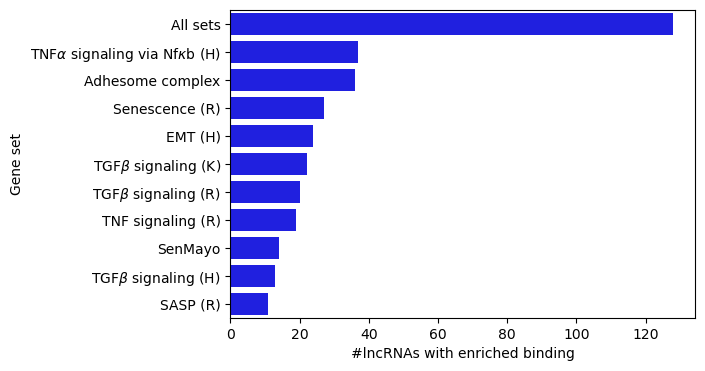

In [102]:
geneset_counts = (
    sig_enr_analyses_results["geneset_short"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=[6, 4])
ax = sns.countplot(
    data=sig_enr_analyses_results,
    y="geneset_short",
    order=geneset_counts.index,
    palette=["b"],
)
ax.set_xlabel("#lncRNAs with enriched binding")
ax.set_ylabel("Gene set")

## Figure S4a

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


Text(0, 0.5, '#lncRNAs')

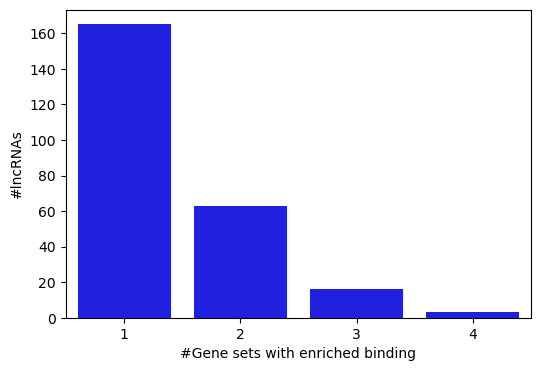

In [103]:
enr_count_by_ncrna = pd.DataFrame(
    sig_enr_analyses_results.groupby("hgnc_symb").count().iloc[:, 0]
)
enr_count_by_ncrna.columns = ["n_enriched_genesets"]
enr_count_by_ncrna_columns = enr_count_by_ncrna.sort_values(
    "n_enriched_genesets", ascending=False
)

fig, ax = plt.subplots(figsize=[6, 4])
ax = sns.countplot(
    data=enr_count_by_ncrna_columns,
    x="n_enriched_genesets",
    palette=["b"],
)
ax.set_xlabel("#Gene sets with enriched binding")
ax.set_ylabel("#lncRNAs")

## Fig S4c

In [104]:
vis_enr_mtx = np.zeros(
    [sig_enr_analyses_results.ncID_ensembl.nunique(), len(aging_genesets)]
)
vis_enr_mtx = pd.DataFrame(
    vis_enr_mtx,
    index=sig_enr_analyses_results.ncID_ensembl.unique(),
    columns=list(aging_genesets.keys()),
)

for ncrna in vis_enr_mtx.index:
    for gs in vis_enr_mtx.columns:
        if (
            len(
                sig_enr_analyses_results.loc[
                    (sig_enr_analyses_results.ncID_ensembl == ncrna)
                    & (sig_enr_analyses_results.geneset == gs)
                ]
            )
            > 0
        ):
            vis_enr_mtx.loc[ncrna, gs] = 1
vis_enr_mtx.index = vis_enr_mtx.index.map(ens2hgnc_dict)
vis_enr_mtx.columns = vis_enr_mtx.columns.map(geneset_short_name_dict)

Text(0.5, 27.444444444444436, 'lncRNAs (256) enriched for aging processes')

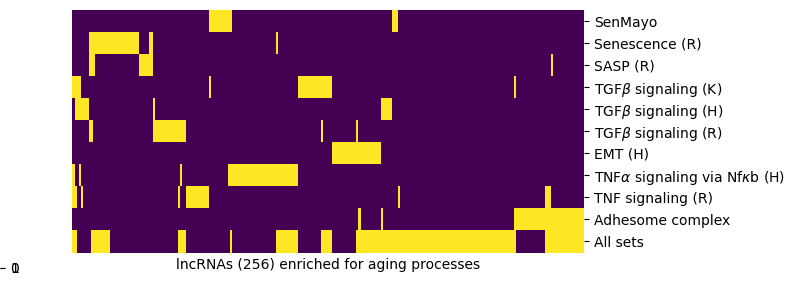

In [105]:
g = sns.clustermap(
    vis_enr_mtx.transpose(),
    col_cluster=True,
    row_cluster=False,
    dendrogram_ratio=0.1,
    cbar_pos=(0, 0, 0, 0),
    figsize=[8, 3],
    cmap="viridis",
    linewidths=0,
    xticklabels=False,
)
colors = {
    "DOWN in OLD": "red",
    "UP in OLD": "green",
}
g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.set_xlabel("lncRNAs (256) enriched for aging processes")

/tmp/ipykernel_3510557/466764245.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = plt.cm.get_cmap("viridis", 256)


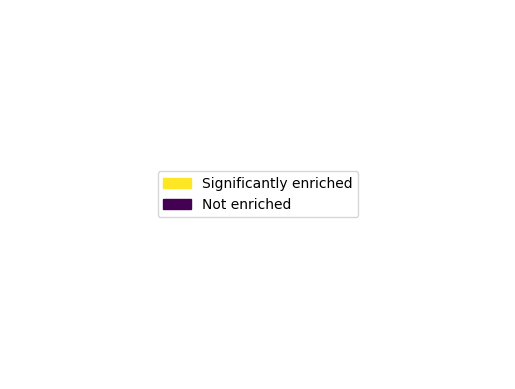

In [106]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Create a binary viridis colormap: 0 = purple, 1 = yellow
viridis = plt.cm.get_cmap("viridis", 256)
binary_cmap = ListedColormap([viridis(0.0), viridis(1.0)])

# Create a custom legend
legend_handles = [
    mpatches.Patch(color=viridis(1.0), label="Significantly enriched"),
    mpatches.Patch(color=viridis(0.0), label="Not enriched"),
]

# Plot the legend only
fig, ax = plt.subplots()
ax.legend(handles=legend_handles, loc="center", borderaxespad=1.5)
ax.axis("off")
plt.show()

## Fig 1e

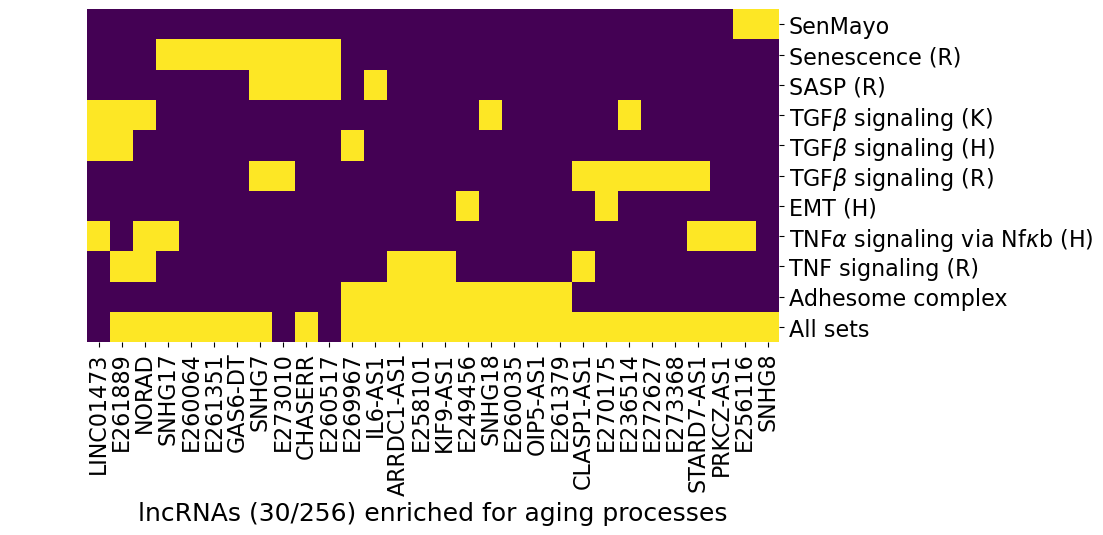

In [107]:
g = sns.clustermap(
    vis_enr_mtx.transpose().loc[:, list(enr_count_by_ncrna_columns.index)[:30]],
    col_cluster=True,
    row_cluster=False,
    dendrogram_ratio=0.1,
    cbar_pos=None,
    figsize=[10, 5],
    cmap="viridis",
    linewidths=0,
    xticklabels=True,
    cbar=False,

)
colors = {
    "DOWN in OLD": "red",
    "UP in OLD": "green",
}
g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.set_xlabel("lncRNAs (30/256) enriched for aging processes", fontsize = 18)
g.ax_heatmap.tick_params(axis='x', labelsize=16)  # change 12 to desired size
g.ax_heatmap.tick_params(axis='y', labelsize=16)  # change 12 to desired size